In [1]:
from deap import tools, creator, base, algorithms, benchmarks
import pymop
from math import factorial
from numpy import random
from meamt_core import generate_dtlz3_front_random, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "dtlz2"
NOBJ = 3
K = 10
NDIM = NOBJ + K - 1
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_dtlz3_front_random(NOBJ, 1000)

In [2]:
MU = 640
NGEN = 500
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)


In [ ]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.dtlz2docs/NSGAIII-dtlz3.ipynb, obj=NOBJ)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

In [4]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        hv_val = hypervolume(pop, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [5]:
pop, logbook = main()

gen	evals	std                               	min                               	avg                               	max                               	hypervolume	igd_plus
0  	640  	[0.55308652 0.53592739 0.59469982]	[0.00071645 0.00010347 0.01230823]	[0.74392866 0.74856905 1.16379432]	[2.14931234 2.13409899 2.43955   ]	           	        
1  	640  	[0.56873002 0.55895997 0.56259477]	[5.93557179e-04 8.57251917e-05 9.01417873e-03]	[0.72423286 0.73404018 0.94575997]	[2.22323789 2.02497177 2.29667096]	0.0982557  	0.328161
2  	640  	[0.5694435  0.55858125 0.54376166]	[5.23694479e-04 7.69114163e-05 4.69964946e-04]	[0.70745873 0.72473139 0.79624101]	[2.22591412 2.08208731 2.29667096]	0.190743   	0.256517
3  	640  	[0.54620446 0.53859048 0.5450591 ]	[1.43314886e-05 7.69114163e-05 3.53627700e-04]	[0.66748352 0.63976416 0.76558735]	[2.26446655 2.08208731 2.14621183]	0.293577   	0.204774
4  	640  	[0.51488865 0.51844478 0.5269947 ]	[2.18566468e-06 7.69114163e-05 3.20459667e-04]	[0.62827655 0.613

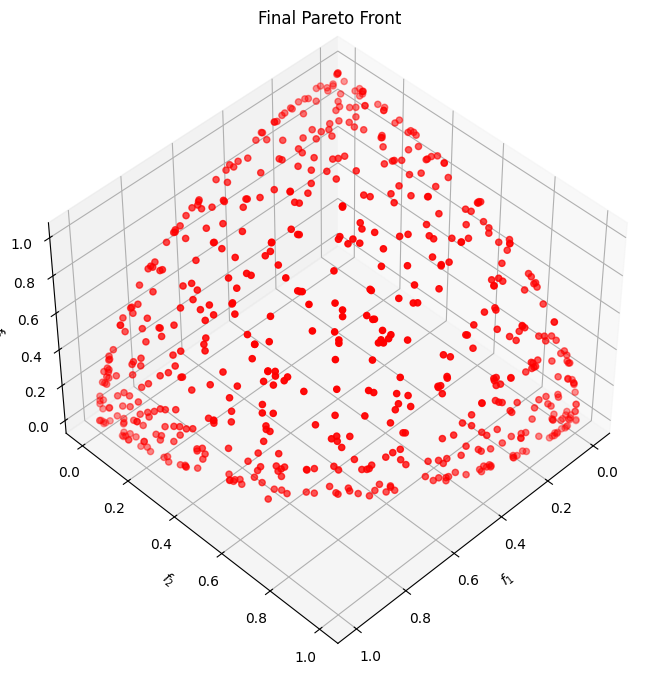

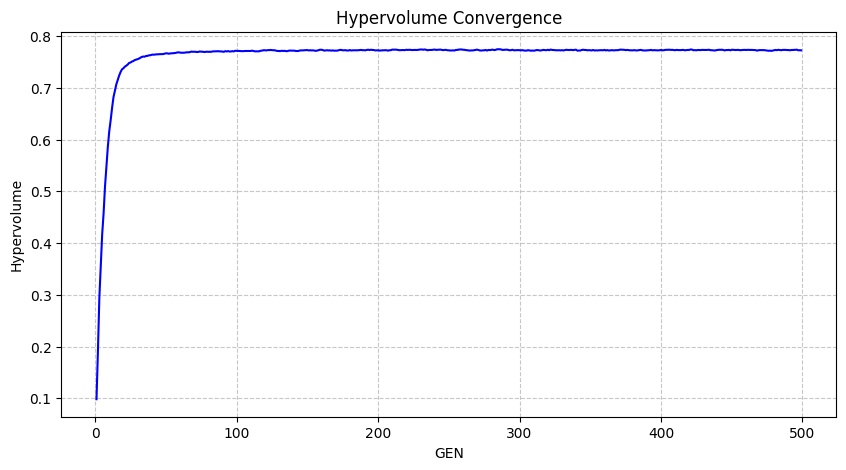

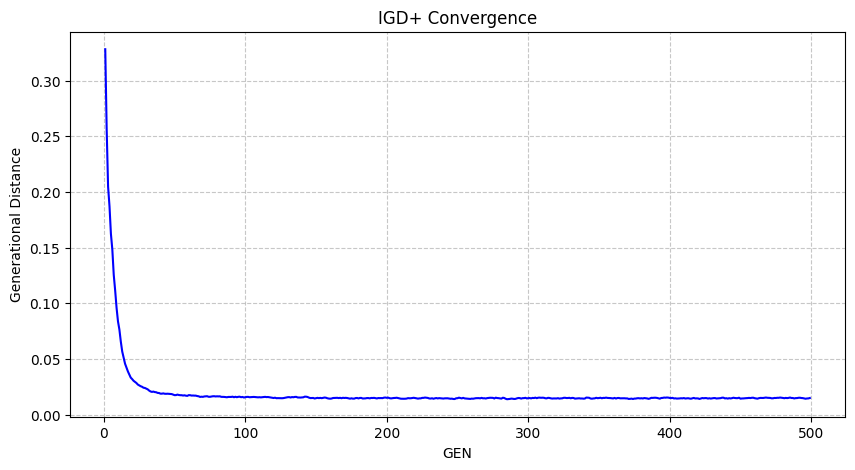

In [6]:
import matplotlib.pyplot as plt

# 3D Graphic of final pareto front
f1 = [ind.fitness.values[0] for ind in pop]
f2 = [ind.fitness.values[1] for ind in pop]
f3 = [ind.fitness.values[2] for ind in pop]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(f1, f2, f3, c='r', marker='o', label='Solutions')
ax.set_title('Final Pareto Front')
ax.set_xlabel('$f_1$')
ax.set_ylabel('$f_2$')
ax.set_zlabel('$f_3$')
ax.view_init(elev=45, azim=45)
plt.show()

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()